In [1]:
import numpy as np
import scipy.stats as st
import seaborn as sb
import matplotlib.pyplot as plt
sb.set()


def p(x):
    return st.norm.pdf(x, loc=30, scale=10) + st.norm.pdf(x, loc=80, scale=20)


def q(x):
    return st.norm.pdf(x, loc=50, scale=30)



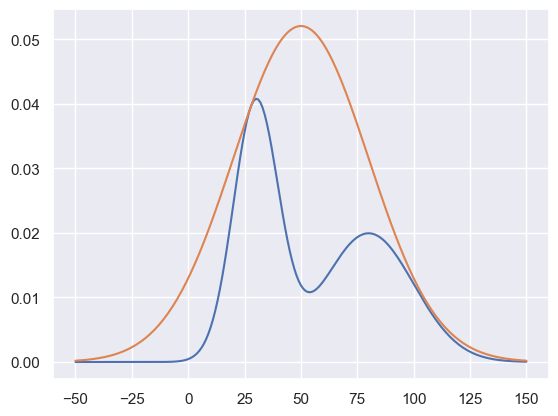

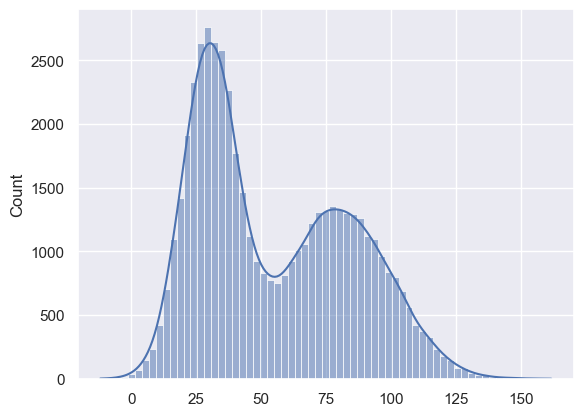

In [2]:
x = np.arange(-50, 151)
k = max(p(x) / q(x))

def rejection_sampling(iter=1000):
    samples = []

    for i in range(iter):
        z = np.random.normal(50, 30)
        u = np.random.uniform(0, k*q(z))

        if u <= p(z):
            samples.append(z)

    return np.array(samples)


if __name__ == '__main__':
    plt.plot(x, p(x))
    plt.plot(x, k*q(x))
    plt.show()

    s = rejection_sampling(iter=100000)
    sb.histplot(s, kde=True)